# Examine relative contribution of fixed and variable processes

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import pytensor
import pytensor.tensor as pt
import pingouin as pg

from devreact import figures
from devreact import model

model_name = 'neural-dual-v7'

fig_dir = Path(os.environ['REMIND_FIGURES']) / 'model' / model_name

%matplotlib inline
figures.set_style()

/Users/morton/PycharmProjects/devreact/.venv/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Get data and parameter estimates from the sample trace

In [2]:
trace = az.from_netcdf(fig_dir / 'trace.nc')

In [3]:
# get posterior point estimates based on mean over trace
var_names = ['τ', 'A', 'b', 'v1_trial', 'v2_trial', 'r', 'v3', 'v4']
post = trace.posterior[var_names].mean(['chain', 'draw'])

In [4]:
# get relevant quantitites from the trace
s = 1
τ = post['τ'].to_numpy()
A = post['A'].to_numpy()
r = post['r'].to_numpy()
b = post['b'][trace.constant_data['subject_index']].to_numpy()
v1 = post['v1_trial'].to_numpy()
v2 = post['v2_trial'].to_numpy()
v3 = post['v3'][trace.constant_data['subject_index']].to_numpy()
v4 = post['v3'][trace.constant_data['subject_index']].to_numpy()

n = trace.constant_data['n'].to_numpy()
rmat = trace.observed_data['response'].to_numpy()

subject = trace.constant_data['subject_index'].to_numpy()
age = trace.constant_data['age'][trace.constant_data['subject_index']].to_numpy()

In [5]:
# define a function to get relevant probabilities based on
# posterior parameter estimates
response_ = pt.dmatrix('r')
n_ = pt.ivector('n')

params = [
    pt.dscalar('s'),
    pt.dscalar('τ'),
    pt.dscalar('A'),
    pt.dvector('b'),
    pt.dvector('v1'),
    pt.dvector('v2'),
    pt.dscalar('r'),
    pt.dvector('v3'),
    pt.dvector('v4'),
]

p, c = model.pdf_dual(response_, n_, *params)
f = pytensor.function([response_, n_, *params], [p, *c])

In [6]:
# calculate probabilities
p, c1, c2, c3 = f(rmat, n, s, τ, A, b, v1, v2, r, v3, v4)

In [7]:
# package relevant quantities into a data frame
# and calculate relative probability of fixed and variable processes
df = (
        pl.DataFrame(
        {
            'subject': subject,
            'Age': age,
            'n': n,
            'response': rmat[:, 0],
            'response_time': rmat[:, 1],
            'p': p,
            'c1': c1,
            'c2': c2,
            'Other': c3,
        }
    )
    .with_columns(
        pl.col('n').cast(pl.String).replace(
            {"1": "Direct", "2": "Indirect"}
        ).alias("Trial type"),
        pl.col("response").cast(pl.Int32).cast(pl.String).replace(
            {"0": "Incorrect", "1": "Correct"}
        ).alias("Response"),
    )
    .with_columns(
        pl.when(pl.col("Response") == "Correct")
        .then(pl.col("c1") / (pl.col("c1") + pl.col("c2")))
        .alias("Fixed-speed"),
        pl.when(pl.col("Response") == "Correct")
        .then(pl.col("c2") / (pl.col("c1") + pl.col("c2")))
        .alias("Variable-speed"),
    )
)

## Get mean relative process contributions for each subject

In [8]:
m = (
    df.filter(pl.col("Response") == "Correct")
    .group_by(["subject", "Age", "Trial type"])
    .agg(pl.col("Fixed-speed").mean(), pl.col("Variable-speed").mean())
    .unpivot(
        ["Fixed-speed", "Variable-speed"], 
        index=["subject", "Age", "Trial type"],
        variable_name="Process",
        value_name="Probability",
    )
)
m.head()

subject,Age,Trial type,Process,Probability
i32,f64,str,str,f64
9,11.259178,"""Indirect""","""Fixed-speed""",0.498852
63,12.858904,"""Direct""","""Fixed-speed""",0.038206
17,8.695068,"""Direct""","""Fixed-speed""",0.181726
5,20.359726,"""Indirect""","""Fixed-speed""",0.56448
52,10.801644,"""Indirect""","""Fixed-speed""",0.595408


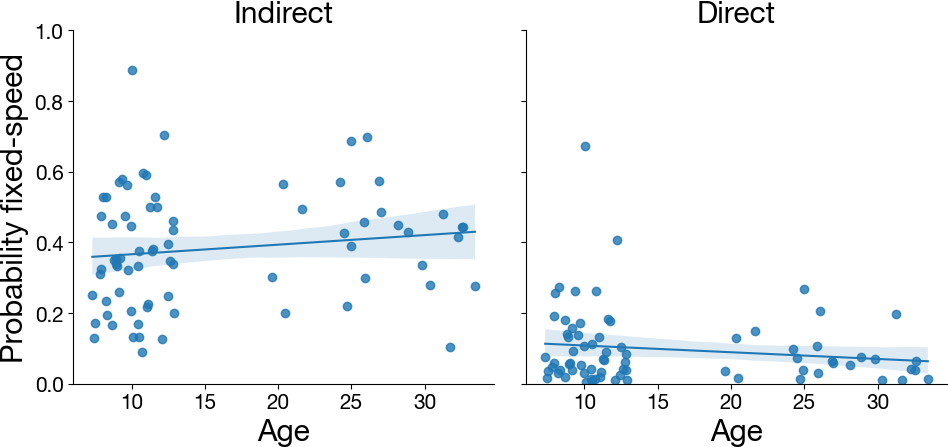

In [9]:
g = sns.lmplot(
    data=m.filter(pl.col("Process") == "Fixed-speed"),
    x="Age",
    y="Probability",
    col="Trial type",
)
g.set(ylabel="Probability fixed-speed", ylim=(0, 1))
g.set_titles(col_template="{col_name}");
g.savefig(fig_dir / "correct_process.pdf")

In [10]:
fixed_direct = m.filter(pl.col("Process") == "Fixed-speed", pl.col("Trial type") == "Direct")
pg.corr(fixed_direct["Age"], fixed_direct["Probability"])

,n,r,CI95,p_val,BF10,power
pearson,74,-0.151219,"[-0.37, 0.08]",0.19841,0.327,0.252305


In [11]:
fixed_direct = m.filter(pl.col("Process") == "Fixed-speed", pl.col("Trial type") == "Indirect")
pg.corr(fixed_direct["Age"], fixed_direct["Probability"])

,n,r,CI95,p_val,BF10,power
pearson,74,0.140219,"[-0.09, 0.36]",0.233428,0.291,0.223117


In [12]:
%load_ext watermark
%watermark -v -iv

Python implementation: CPython
Python version       : 3.13.6
IPython version      : 9.12.0

arviz     : 0.23.4
devreact  : 0.1.0
matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
pingouin  : 0.6.1
polars    : 1.44.1
pytensor  : 2.38.2
seaborn   : 0.13.2

